## Importing Libraries

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
import spotipy
import scipy.stats as stats
from spotipy.oauth2 import SpotifyClientCredentials
from spotipy.oauth2 import SpotifyOAuth
import pandas as pd
import numpy as np
import seaborn as sns
import re
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from feature_engine.discretisation import EqualWidthDiscretiser
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import precision_recall_curve
import joblib

In [2]:
#song_data = pd.read_csv('song_data.csv')

## Extracting Data

In [3]:
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(client_id='c19ae55b5ae34d2d859674dd6147ce80',
                                               client_secret='6b3a38830dcd424098884964307b1c22',
                                               redirect_uri='http://localhost:6969/callback'))

In [4]:
playlist_ids = ['37i9dQZF1DX2M1RktxUUHG','37i9dQZF1DX5Ejj0EkURtP','37i9dQZF1DX4o1oenSJRJd',
                '37i9dQZF1DXbTxeAdrVG2l','37i9dQZF1DX4UtSsGT1Sbe','37i9dQZF1DWTJ7xPn4vNaz',
                '37i9dQZF1DXaKIA8E7WcJj','37i9dQZF1DWSV3Tk4GO2fq']

In [5]:
def get_track_features(track_id, playlist_name, playlist_id):
    track_info = sp.track(track_id)
    features = sp.audio_features(track_id)[0]

    if features is None:
        return {
            'Playlist_Name': playlist_name,
            'Playlist_ID': playlist_id,
            'Track_Name': track_info['name'],
            'Track_ID': track_id,
            'Duration_ms': track_info['duration_ms']
        }

    return {
        'Playlist_Name': playlist_name,
        'Playlist_ID': playlist_id,
        'Track_Name': track_info['name'],
        'Track_ID': track_id,
        'Duration_ms': track_info['duration_ms'],
        'Danceability': features['danceability'],
        'Energy': features['energy'],
        'Key': features['key'],
        'Loudness': features['loudness'],
        'Mode': features['mode'],
        'Speechiness': features['speechiness'],
        'Acousticness': features['acousticness'],
        'Instrumentalness': features['instrumentalness'],
        'Liveness': features['liveness'],
        'Valence': features['valence'],
        'Time_Signature': features['time_signature'],
        'Tempo': features['tempo']
    }

In [6]:
def get_playlist_tracks(playlist_id):
    playlist_info = sp.playlist(playlist_id)
    playlist_name = playlist_info['name']
    tracks = []
    results = sp.playlist_tracks(playlist_id)
    
    if results is None:
        return []
    
    tracks.extend(results['items'])

    while results['next']:
        results = sp.next(results)
        if results is None:
            break
        tracks.extend(results['items'])

    track_features = []
    for item in tracks:
        track = item['track']
        track_id = track['id']
        if track_id:  # Ensure the track ID is valid
            features = get_track_features(track_id, playlist_name, playlist_id)
            if features is not None:
                track_features.append(features)
    
    return track_features

In [7]:
song_data = []
for playlist_id in playlist_ids:
    songs = get_playlist_tracks(playlist_id)
    song_data.extend(songs)

song_data = pd.DataFrame(song_data)

In [8]:
song_data.to_csv('song_data.csv', index=False)

## Understanding the Data

In [9]:
song_data = pd.read_csv('song_data.csv')

In [10]:
song_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Playlist_Name     1200 non-null   object 
 1   Playlist_ID       1200 non-null   object 
 2   Track_Name        1200 non-null   object 
 3   Track_ID          1200 non-null   object 
 4   Duration_ms       1200 non-null   int64  
 5   Danceability      1199 non-null   float64
 6   Energy            1199 non-null   float64
 7   Key               1199 non-null   float64
 8   Loudness          1199 non-null   float64
 9   Mode              1199 non-null   float64
 10  Speechiness       1199 non-null   float64
 11  Acousticness      1199 non-null   float64
 12  Instrumentalness  1199 non-null   float64
 13  Liveness          1199 non-null   float64
 14  Valence           1199 non-null   float64
 15  Time_Signature    1199 non-null   float64
 16  Tempo             1199 non-null   float64


In [11]:
song_data.head()

,Playlist_Name,Playlist_ID,Track_Name,Track_ID,Duration_ms,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Time_Signature,Tempo
0,All Out 2020s,37i9dQZF1DX2M1RktxUUHG,Kiss Me More (feat. SZA),3DarAbFujv6eYNliUTyqtz,208666,0.764,0.705,8.0,-3.463,1.0,0.0284,0.2590,0.000089,0.120,0.781,4.0,110.970
1,All Out 2020s,37i9dQZF1DX2M1RktxUUHG,Wonder,5KCbr5ndeby4y4ggthdiAb,172692,0.333,0.637,1.0,-4.904,0.0,0.0581,0.1310,0.000018,0.149,0.132,4.0,139.898
2,All Out 2020s,37i9dQZF1DX2M1RktxUUHG,Ghost,6I3mqTwhRpn34SLVafSH7G,153190,0.601,0.741,2.0,-5.569,1.0,0.0478,0.1850,0.000029,0.415,0.441,4.0,153.960
3,All Out 2020s,37i9dQZF1DX2M1RktxUUHG,deja vu,6HU7h9RYOaPRFeh0R3UeAr,215506,0.442,0.612,2.0,-7.222,1.0,0.1120,0.5840,0.000006,0.370,0.178,4.0,180.917
4,All Out 2020s,37i9dQZF1DX2M1RktxUUHG,Kill Bill,1Qrg8KqiBpW07V7PNxwwwL,153946,0.644,0.735,8.0,-5.747,1.0,0.0391,0.0521,0.144000,0.161,0.418,4.0,88.980


In [12]:
song_data.describe(include='all')

,Playlist_Name,Playlist_ID,Track_Name,Track_ID,Duration_ms,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Time_Signature,Tempo
count,1200,1200,1200,1200,1200.000000,1199.000000,1199.000000,1199.000000,1199.000000,1199.000000,1199.000000,1199.000000,1199.000000,1199.000000,1199.000000,1199.000000,1199.000000
unique,8,8,1172,1193,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,All Out 2020s,37i9dQZF1DX2M1RktxUUHG,Here With Me,7oOOI85fVQvVnK5ynNMdW7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,150,150,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,217163.212500,0.590684,0.591274,5.051710,-8.287736,0.742285,0.056642,0.336477,0.010595,0.170729,0.557788,3.915763,119.754118
std,NaN,NaN,NaN,NaN,57432.989077,0.146216,0.214771,3.534329,3.707203,0.437559,0.051143,0.301402,0.061919,0.131111,0.247777,0.342450,28.021579
min,NaN,NaN,NaN,NaN,97392.000000,0.138000,0.007560,0.000000,-26.440000,0.000000,0.022700,0.000018,0.000000,0.020700,0.034800,1.000000,60.300000
25%,NaN,NaN,NaN,NaN,175450.750000,0.500500,0.446500,2.000000,-10.363000,0.000000,0.031500,0.061750,0.000000,0.091000,0.348500,4.000000,98.694000
50%,NaN,NaN,NaN,NaN,212119.500000,0.597000,0.617000,5.000000,-7.536000,1.000000,0.039100,0.245000,0.000002,0.119000,0.559000,4.000000,118.469000
75%,NaN,NaN,NaN,NaN,247276.500000,0.696500,0.759500,8.000000,-5.496000,1.000000,0.057500,0.592500,0.000128,0.209000,0.774500,4.000000,136.038500


In [13]:
song_data.isnull().mean()

Playlist_Name       0.000000
Playlist_ID         0.000000
Track_Name          0.000000
Track_ID            0.000000
Duration_ms         0.000000
Danceability        0.000833
Energy              0.000833
Key                 0.000833
Loudness            0.000833
Mode                0.000833
Speechiness         0.000833
Acousticness        0.000833
Instrumentalness    0.000833
Liveness            0.000833
Valence             0.000833
Time_Signature      0.000833
Tempo               0.000833
dtype: float64

In [14]:
song_data.nunique()

Playlist_Name          8
Playlist_ID            8
Track_Name          1172
Track_ID            1193
Duration_ms         1150
Danceability         513
Energy               620
Key                   12
Loudness            1129
Mode                   2
Speechiness          524
Acousticness         862
Instrumentalness     577
Liveness             564
Valence              661
Time_Signature         4
Tempo               1183
dtype: int64

## Exploratory Data Analysis (Numerical Variables)

In [15]:
song_eda = song_data.copy()

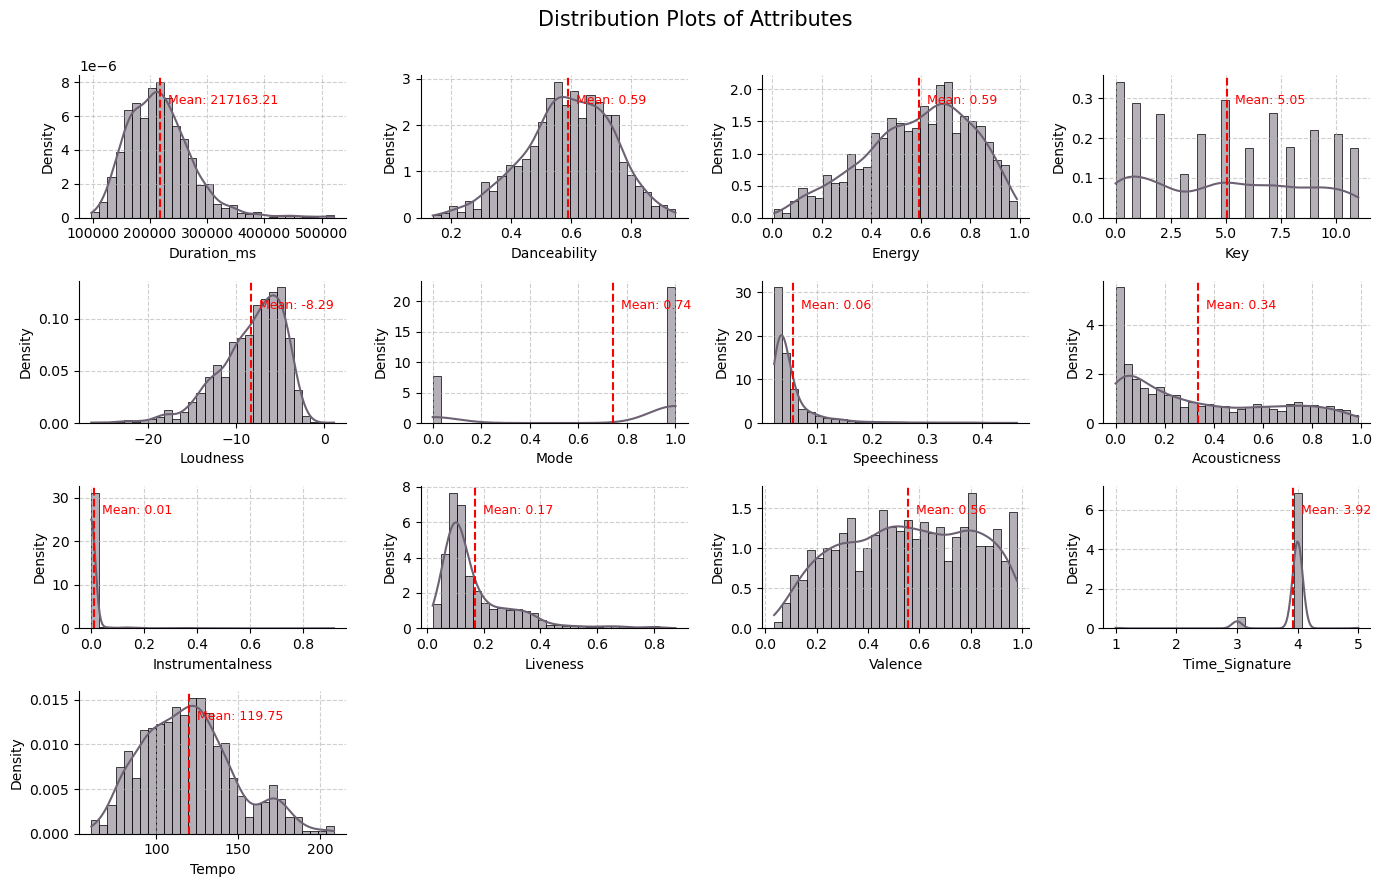

In [16]:
num_cols_eda = [n for n in song_eda.columns if song_eda[n].dtypes!='O']

fig, ax = plt.subplots(4, 4, figsize=(14, 9))
ax = ax.flatten()

for i, col in enumerate(num_cols_eda):
    sns.histplot(song_eda[col],kde=True,stat='density',bins=30,ax=ax[i],color='#6d6273')
    mean_val = song_eda[col].mean()  
    ax[i].axvline(mean_val, color='red', linestyle='--')
    ax[i].text(mean_val, ax[i].get_ylim()[1] * 0.8, f'  Mean: {mean_val:.2f}', color='red', fontsize=9, ha='left')
    ax[i].grid(True, linestyle='--', alpha=0.6)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

for i in range(len(num_cols_eda),16):
    ax[i].axis('off')

fig.suptitle('Distribution Plots of Attributes', size=15)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

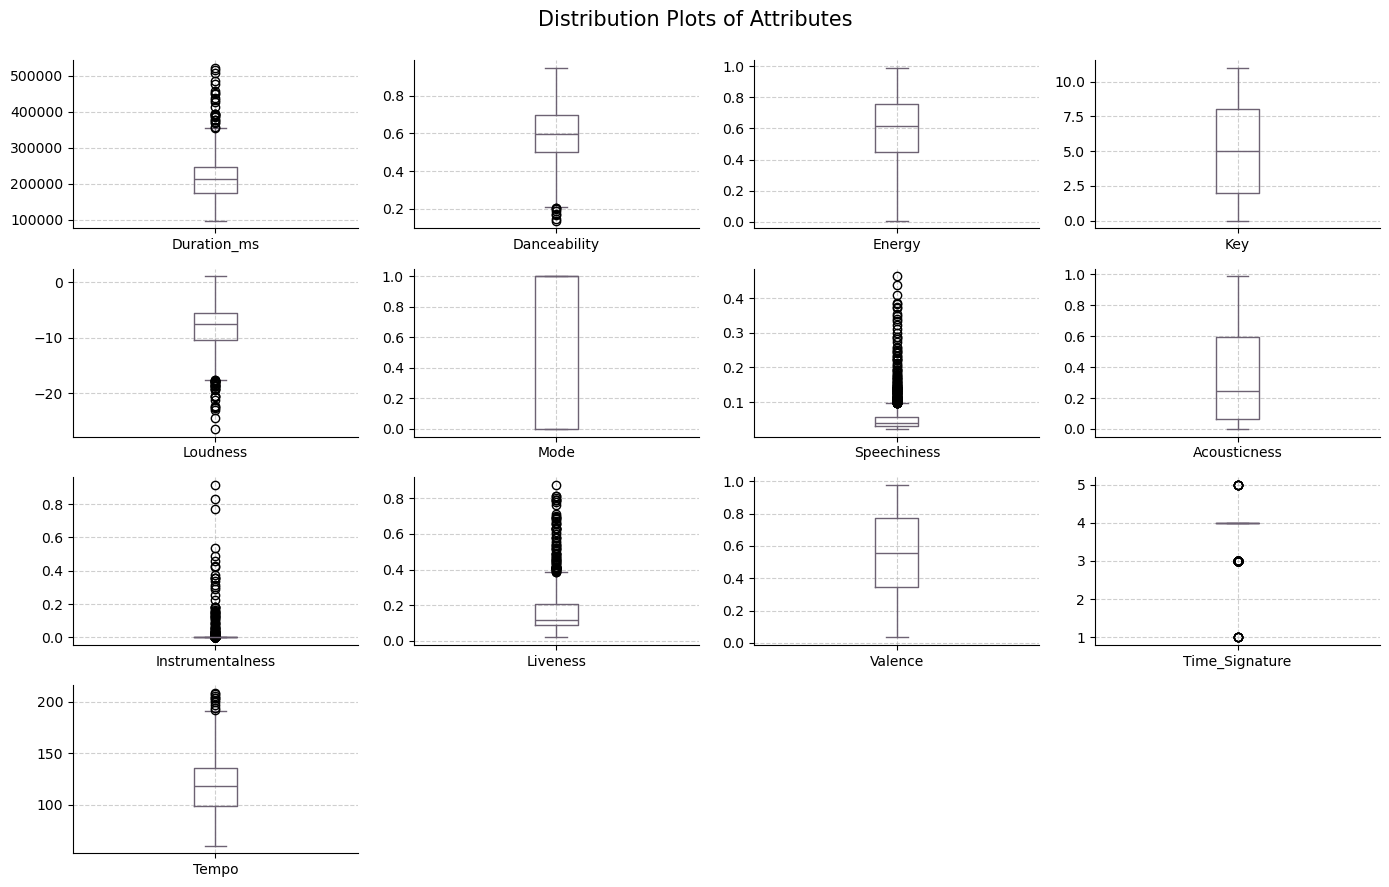

In [17]:
fig, ax = plt.subplots(4, 4, figsize=(14, 9))
ax = ax.flatten()

for i, col in enumerate(num_cols_eda):
    song_eda.boxplot(col, ax=ax[i],color='#6d6273')
    ax[i].grid(True, linestyle='--', alpha=0.6)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

for i in range(len(num_cols_eda),16):
    ax[i].axis('off')

fig.suptitle('Distribution Plots of Attributes', size=15)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

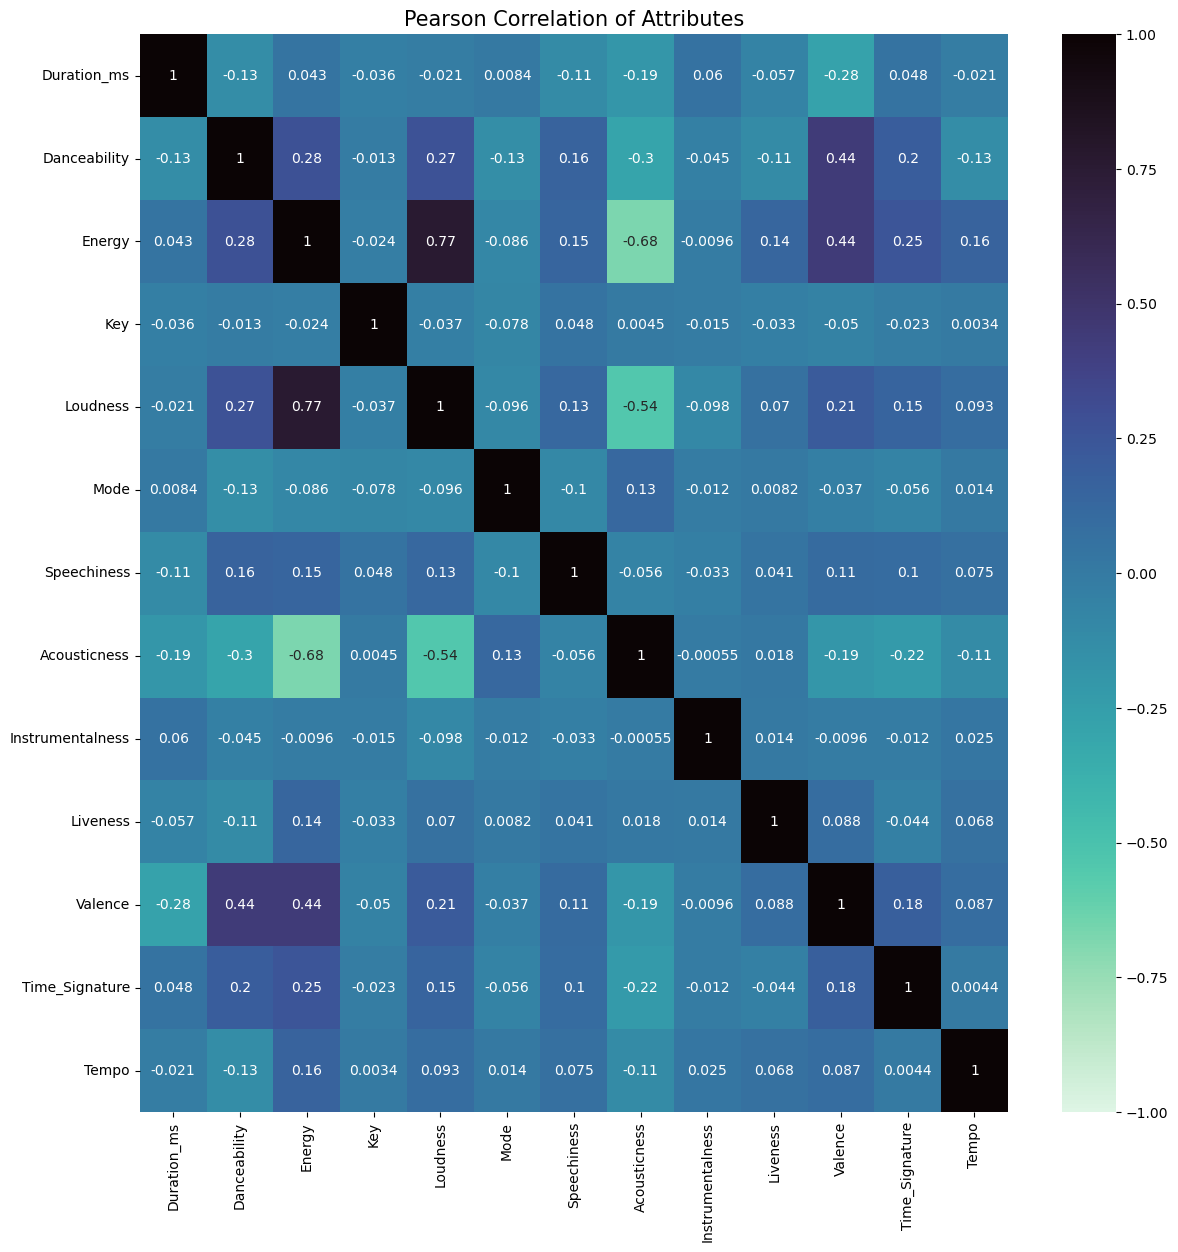

In [18]:
plt.figure(figsize=(14,14))
plt.title('Pearson Correlation of Attributes', size=15)
ax = sns.heatmap(song_eda[num_cols_eda].corr(), cmap='mako_r', annot=True, vmin=-1, vmax=1)
plt.show()

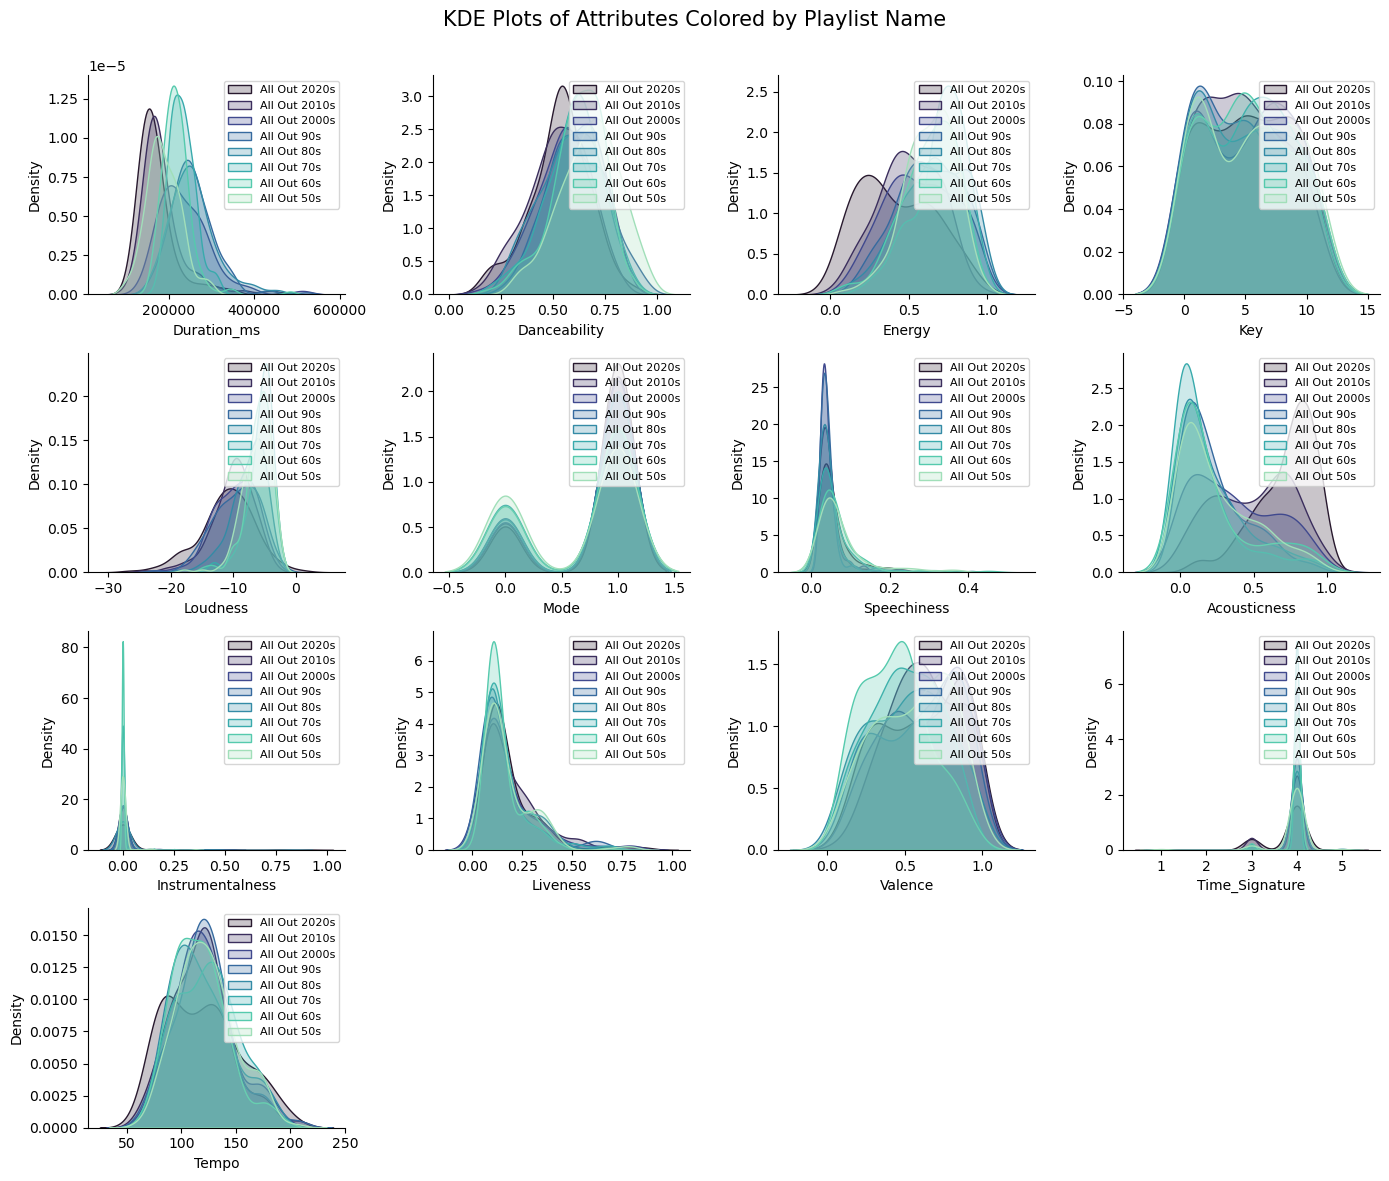

In [19]:
fig, ax = plt.subplots(4, 4, figsize=(14, 12))
ax = ax.flatten()

for i, col in enumerate(num_cols_eda):
    sns.kdeplot(data=song_eda, x=col, hue='Playlist_Name', fill=True, common_norm=False, ax=ax[i], palette='mako_r')
    ax[i].legend(song_eda['Playlist_Name'].unique(),fontsize=8)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

for i in range(len(num_cols_eda), 16):
    ax[i].axis('off')

fig.suptitle('KDE Plots of Attributes Colored by Playlist Name', size=15)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

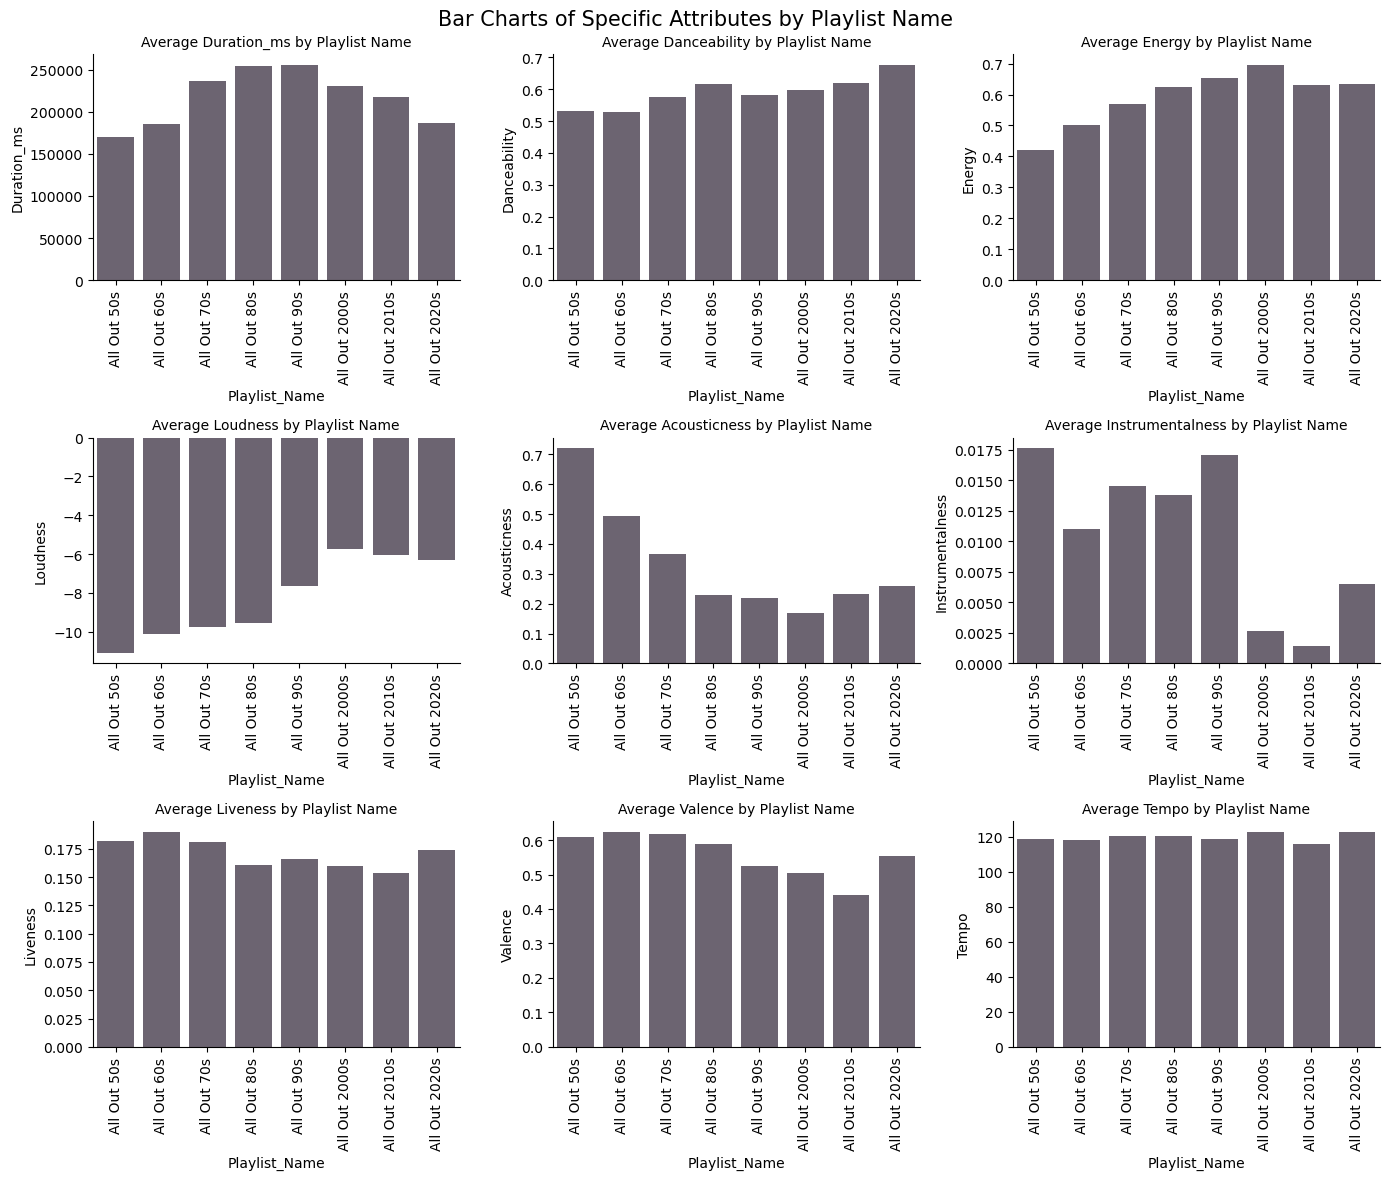

In [20]:
playlist_order = ['All Out 50s', 'All Out 60s', 'All Out 70s', 'All Out 80s', 'All Out 90s', 'All Out 2000s', 'All Out 2010s', 'All Out 2020s']
columns_to_plot = ['Duration_ms', 'Danceability', 'Energy', 'Loudness', 'Acousticness','Instrumentalness', 'Liveness', 'Valence', 'Tempo']

fig, ax = plt.subplots(3, 3, figsize=(14, 12))
ax = ax.flatten()

for i, col in enumerate(columns_to_plot):
    avg_by_playlist = song_eda.groupby('Playlist_Name')[col].mean().reset_index()
    avg_by_playlist['Playlist_Name'] = pd.Categorical(avg_by_playlist['Playlist_Name'], categories=playlist_order, ordered=True)
    sns.barplot(data=avg_by_playlist, x='Playlist_Name', y=col, ax=ax[i],color='#6d6273')
    ax[i].set_title(f'Average {col} by Playlist Name', fontsize=10)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].tick_params(axis='x', rotation=90)

fig.suptitle('Bar Charts of Specific Attributes by Playlist Name', size=15)
plt.tight_layout()
plt.show()

## Exploratory Data Analysis (Categorical Variables)

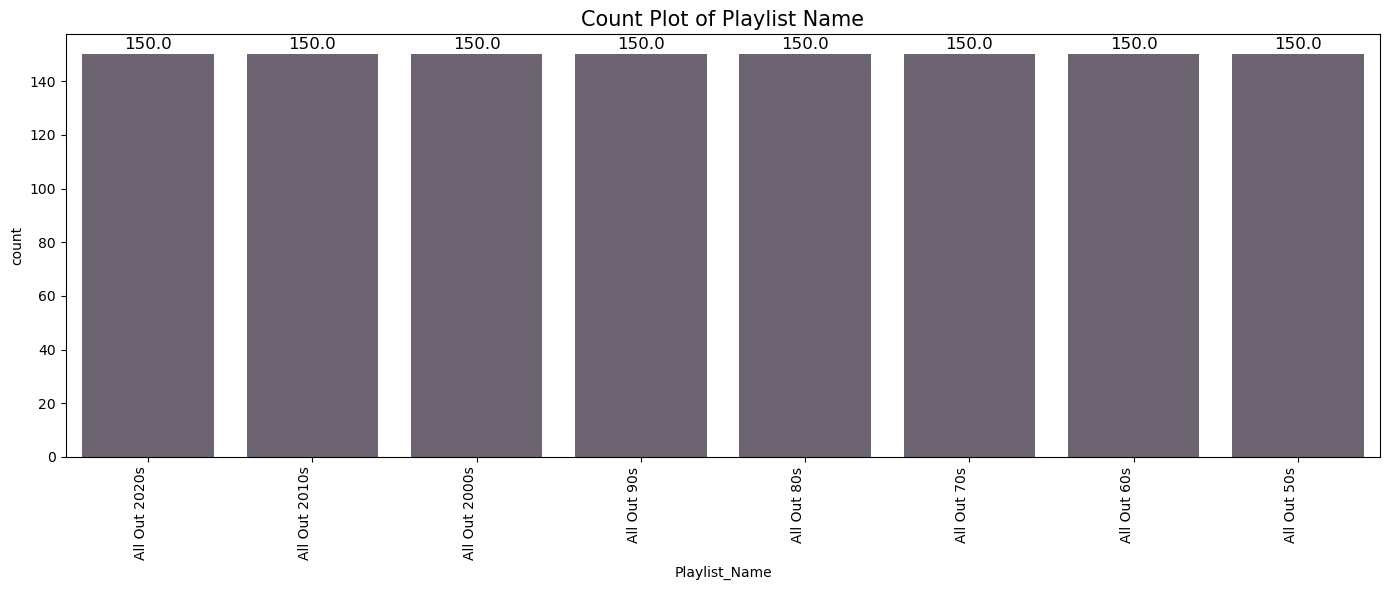

In [21]:
plt.figure(figsize=(14, 6))
ax = sns.countplot(x='Playlist_Name', data=song_eda,color='#6d6273')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 4), 
                textcoords='offset points')
plt.xticks(rotation=90, ha='right')
plt.title('Count Plot of Playlist Name', size=15)
plt.tight_layout()
plt.show()

## Exploratory Data Analysis (Missing Data)

In [22]:
null_records = song_eda[song_eda.isnull().any(axis=1)]
null_records

,Playlist_Name,Playlist_ID,Track_Name,Track_ID,Duration_ms,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Time_Signature,Tempo
445,All Out 2000s,37i9dQZF1DX4o1oenSJRJd,I Write Sins Not Tragedies,5cY8y2XgOfkAh4kSWLFKkz,185586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Preprocessing (Target Variable)

In [23]:
song_data = song_data.dropna()
song_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1199 entries, 0 to 1199
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Playlist_Name     1199 non-null   object 
 1   Playlist_ID       1199 non-null   object 
 2   Track_Name        1199 non-null   object 
 3   Track_ID          1199 non-null   object 
 4   Duration_ms       1199 non-null   int64  
 5   Danceability      1199 non-null   float64
 6   Energy            1199 non-null   float64
 7   Key               1199 non-null   float64
 8   Loudness          1199 non-null   float64
 9   Mode              1199 non-null   float64
 10  Speechiness       1199 non-null   float64
 11  Acousticness      1199 non-null   float64
 12  Instrumentalness  1199 non-null   float64
 13  Liveness          1199 non-null   float64
 14  Valence           1199 non-null   float64
 15  Time_Signature    1199 non-null   float64
 16  Tempo             1199 non-null   float64
dtype

In [24]:
def extract_decade(playlist_name):
    match = re.search(r'(\d{2,4})s', playlist_name)
    if match:
        # Convert '50s' to '1950s', '90s' to '1990s', and '2020s' stays the same
        decade = match.group(1)
        if len(decade) == 2:  # For cases like '50s', '90s'
            return f"19{decade}s"
        else:
            return f"{decade}s"
    return None
    
song_data['Decade'] = song_data['Playlist_Name'].apply(extract_decade)

In [25]:
decade_mapping = {
    '2020s': '2010s-2020s',
    '2010s': '2010s-2020s',
    '2000s': '1990s-2000s',
    '1990s': '1990s-2000s',
    '1980s': '1970s-1980s',
    '1970s': '1970s-1980s',
    '1960s': '1950s-1960s',
    '1950s': '1950s-1960s'
}

song_data['Decade_Range'] = song_data['Decade'].map(decade_mapping)

In [26]:
le = LabelEncoder()
song_data['Decade_Range'] = le.fit_transform(song_data['Decade_Range'])

In [27]:
song_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1199 entries, 0 to 1199
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Playlist_Name     1199 non-null   object 
 1   Playlist_ID       1199 non-null   object 
 2   Track_Name        1199 non-null   object 
 3   Track_ID          1199 non-null   object 
 4   Duration_ms       1199 non-null   int64  
 5   Danceability      1199 non-null   float64
 6   Energy            1199 non-null   float64
 7   Key               1199 non-null   float64
 8   Loudness          1199 non-null   float64
 9   Mode              1199 non-null   float64
 10  Speechiness       1199 non-null   float64
 11  Acousticness      1199 non-null   float64
 12  Instrumentalness  1199 non-null   float64
 13  Liveness          1199 non-null   float64
 14  Valence           1199 non-null   float64
 15  Time_Signature    1199 non-null   float64
 16  Tempo             1199 non-null   float64
 17  

## Data Preprocessing (Base)

In [28]:
song_data_base = song_data.drop(columns=['Playlist_Name','Playlist_ID','Track_Name','Track_ID','Decade'])

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    song_data_base.drop('Decade_Range', axis=1), song_data_base['Decade_Range'], test_size=0.2, random_state=420,stratify=song_data['Decade_Range'])

X_train.shape, X_test.shape

((959, 13), (240, 13))

In [30]:
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [31]:
classifiers = [
    KNeighborsClassifier(), 
    GradientBoostingClassifier(random_state=420),
    ExtraTreesClassifier(random_state=420),
    RandomForestClassifier(random_state=420),
    DecisionTreeClassifier(random_state=420),
    LogisticRegression(),
    SVC()
]

for model in classifiers:
    if isinstance(model, (KNeighborsClassifier, LogisticRegression, SVC)):
        X_train_data, X_test_data = X_train_scaled, X_test_scaled
    else:
        X_train_data, X_test_data = X_train, X_test
    
    model.fit(X_train_data, y_train)
    
    y_test_pred = model.predict(X_test_data)
    
    
    print(model)
    print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.3f}")
    print(classification_report(y_test, y_test_pred, target_names=le.classes_))
    print()

KNeighborsClassifier()
Accuracy: 0.546
              precision    recall  f1-score   support

 1950s-1960s       0.77      0.73      0.75        60
 1970s-1980s       0.51      0.55      0.53        60
 1990s-2000s       0.37      0.35      0.36        60
 2010s-2020s       0.54      0.55      0.55        60

    accuracy                           0.55       240
   macro avg       0.55      0.55      0.55       240
weighted avg       0.55      0.55      0.55       240


GradientBoostingClassifier(random_state=420)
Accuracy: 0.650
              precision    recall  f1-score   support

 1950s-1960s       0.85      0.78      0.82        60
 1970s-1980s       0.60      0.60      0.60        60
 1990s-2000s       0.52      0.53      0.53        60
 2010s-2020s       0.64      0.68      0.66        60

    accuracy                           0.65       240
   macro avg       0.65      0.65      0.65       240
weighted avg       0.65      0.65      0.65       240


ExtraTreesClassifier(random_

## Data Preprocessing (Improved)

In [32]:
song_data_imp = song_data.drop(columns=['Playlist_Name','Playlist_ID','Track_Name','Track_ID','Decade'])

In [33]:
song_clustering = song_data_imp.drop(columns=['Decade_Range'])
a_scaler = StandardScaler()
a_scaler.fit(song_clustering)
song_clustering_scaled = a_scaler.transform(song_clustering)

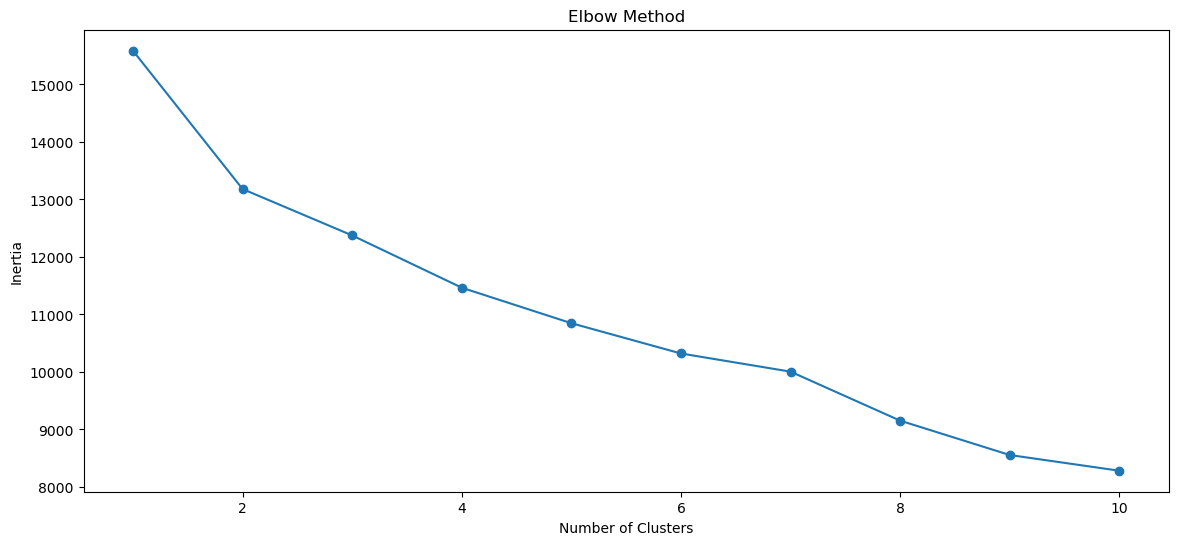

In [34]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=420)
    kmeans.fit(song_clustering_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(14,6))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [35]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=420)
clusters = kmeans.fit_predict(song_clustering_scaled)

song_data_imp['Cluster'] = clusters
song_data_imp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1199 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Duration_ms       1199 non-null   int64  
 1   Danceability      1199 non-null   float64
 2   Energy            1199 non-null   float64
 3   Key               1199 non-null   float64
 4   Loudness          1199 non-null   float64
 5   Mode              1199 non-null   float64
 6   Speechiness       1199 non-null   float64
 7   Acousticness      1199 non-null   float64
 8   Instrumentalness  1199 non-null   float64
 9   Liveness          1199 non-null   float64
 10  Valence           1199 non-null   float64
 11  Time_Signature    1199 non-null   float64
 12  Tempo             1199 non-null   float64
 13  Decade_Range      1199 non-null   int32  
 14  Cluster           1199 non-null   int32  
dtypes: float64(12), int32(2), int64(1)
memory usage: 140.5 KB


In [36]:
cols = song_data_imp.columns.tolist()

cols.remove('Decade_Range')  
cols.append('Decade_Range') 
song_data_imp = song_data_imp[cols]

In [37]:
song_data_imp.head()

,Duration_ms,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Time_Signature,Tempo,Cluster,Decade_Range
0,208666,0.764,0.705,8.0,-3.463,1.0,0.0284,0.2590,0.000089,0.120,0.781,4.0,110.970,3,3
1,172692,0.333,0.637,1.0,-4.904,0.0,0.0581,0.1310,0.000018,0.149,0.132,4.0,139.898,0,3
2,153190,0.601,0.741,2.0,-5.569,1.0,0.0478,0.1850,0.000029,0.415,0.441,4.0,153.960,3,3
3,215506,0.442,0.612,2.0,-7.222,1.0,0.1120,0.5840,0.000006,0.370,0.178,4.0,180.917,3,3
4,153946,0.644,0.735,8.0,-5.747,1.0,0.0391,0.0521,0.144000,0.161,0.418,4.0,88.980,3,3


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    song_data_imp.drop('Decade_Range', axis=1), song_data_imp['Decade_Range'], test_size=0.2, random_state=420,stratify=song_data_imp['Decade_Range'])

X_train.shape, X_test.shape

((959, 14), (240, 14))

In [39]:
ewd_lo_disc = EqualWidthDiscretiser(bins=5, variables = ['Loudness'])
ewd_lo_disc.fit(X_train)

EqualWidthDiscretiser(bins=5, variables=['Loudness'])

In [40]:
X_train = ewd_lo_disc.transform(X_train)
X_test = ewd_lo_disc.transform(X_test)

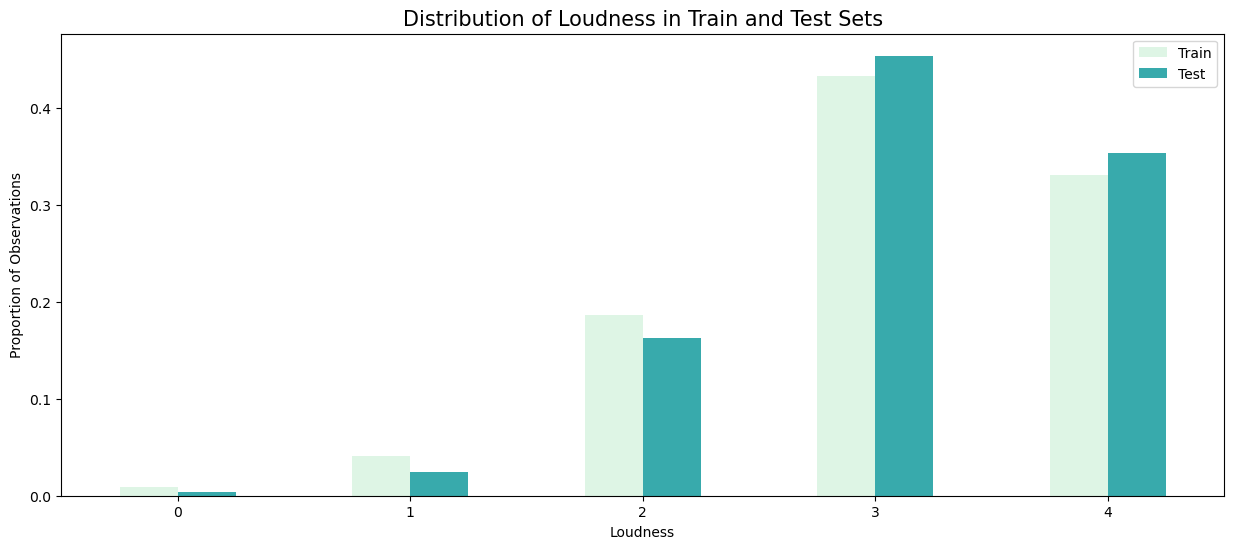

In [41]:
t1 = X_train.groupby(['Loudness'])['Loudness'].count() / len(X_train)
t2 = X_test.groupby(['Loudness'])['Loudness'].count() / len(X_test)

tmp = pd.concat([t1, t2], axis=1)
tmp.columns = ['Train', 'Test']

cmap = plt.get_cmap('mako_r')
tmp.plot(kind='bar', figsize=(15, 6), color=[cmap(i) for i in np.linspace(0, 1, 4)])
plt.xticks(rotation=0)
plt.ylabel('Proportion of Observations')
plt.title('Distribution of Loudness in Train and Test Sets',size=15)
plt.show()

In [42]:
feature_names = X_train.columns
b_scaler = StandardScaler()
b_scaler.fit(X_train)

X_train_scaled = b_scaler.transform(X_train)
X_test_scaled = b_scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names)

In [43]:
classifiers = [
    KNeighborsClassifier(), 
    GradientBoostingClassifier(random_state=420),
    ExtraTreesClassifier(random_state=420),
    RandomForestClassifier(random_state=420),
    DecisionTreeClassifier(random_state=420),
    LogisticRegression(),
    SVC()
]

for model in classifiers:
    if isinstance(model, (KNeighborsClassifier, LogisticRegression, SVC)):
        X_train_data, X_test_data = X_train_scaled, X_test_scaled
    else:
        X_train_data, X_test_data = X_train, X_test
    
    model.fit(X_train_data, y_train)
    
    y_test_pred = model.predict(X_test_data)
    
    
    print(model)
    print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.3f}")
    print(classification_report(y_test, y_test_pred, target_names=le.classes_))
    print()


KNeighborsClassifier()
Accuracy: 0.529
              precision    recall  f1-score   support

 1950s-1960s       0.70      0.75      0.73        60
 1970s-1980s       0.48      0.52      0.50        60
 1990s-2000s       0.40      0.35      0.37        60
 2010s-2020s       0.52      0.50      0.51        60

    accuracy                           0.53       240
   macro avg       0.52      0.53      0.53       240
weighted avg       0.52      0.53      0.53       240


GradientBoostingClassifier(random_state=420)
Accuracy: 0.646
              precision    recall  f1-score   support

 1950s-1960s       0.81      0.73      0.77        60
 1970s-1980s       0.55      0.60      0.58        60
 1990s-2000s       0.60      0.57      0.58        60
 2010s-2020s       0.64      0.68      0.66        60

    accuracy                           0.65       240
   macro avg       0.65      0.65      0.65       240
weighted avg       0.65      0.65      0.65       240


ExtraTreesClassifier(random_

In [44]:
param_grid = {
    'n_estimators': [100, 200, 300],            
    'min_samples_leaf': [1, 2, 4],              
    'max_depth': [10, 20, 30, None],            
    'max_features': ['sqrt', 'log2'],           
    'bootstrap': [True, False]                  
}

rf = RandomForestClassifier(random_state=420)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2)

grid_search.fit(X_train, y_train)
print(f"Best Parameters: {grid_search.best_params_}")
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best Parameters: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 100}
Accuracy: 0.708
              precision    recall  f1-score   support

 1950s-1960s       0.84      0.82      0.83        60
 1970s-1980s       0.60      0.65      0.62        60
 1990s-2000s       0.63      0.63      0.63        60
 2010s-2020s       0.77      0.73      0.75        60

    accuracy                           0.71       240
   macro avg       0.71      0.71      0.71       240
weighted avg       0.71      0.71      0.71       240



In [45]:
best_rf

RandomForestClassifier(max_depth=10, min_samples_leaf=2, random_state=420)

In [46]:
seeds = [42, 100, 420, 1010, 2023]

cv_folds = 5

results = {}

for seed in seeds:
    print(f"Evaluating RandomForest with random_state={seed}")
    
    rf = RandomForestClassifier(max_depth=10, min_samples_leaf=2, random_state=seed)
    
    cv_scores = cross_val_score(rf, X_train, y_train, cv=cv_folds, scoring='accuracy', n_jobs=-1)
    
    results[seed] = cv_scores
    
    print(f"Mean Accuracy: {np.mean(cv_scores):.4f}, Std Deviation: {np.std(cv_scores):.4f}\n")

all_scores = [np.mean(results[seed]) for seed in seeds]
overall_mean = np.mean(all_scores)
overall_std = np.std(all_scores)

print(f"Overall Mean Accuracy: {overall_mean:.4f}, Overall Std Dev: {overall_std:.4f}")

Evaluating RandomForest with random_state=42
Mean Accuracy: 0.6277, Std Deviation: 0.0159

Evaluating RandomForest with random_state=100
Mean Accuracy: 0.6277, Std Deviation: 0.0103

Evaluating RandomForest with random_state=420
Mean Accuracy: 0.6361, Std Deviation: 0.0150

Evaluating RandomForest with random_state=1010
Mean Accuracy: 0.6288, Std Deviation: 0.0128

Evaluating RandomForest with random_state=2023
Mean Accuracy: 0.6205, Std Deviation: 0.0176

Overall Mean Accuracy: 0.6282, Overall Std Dev: 0.0050


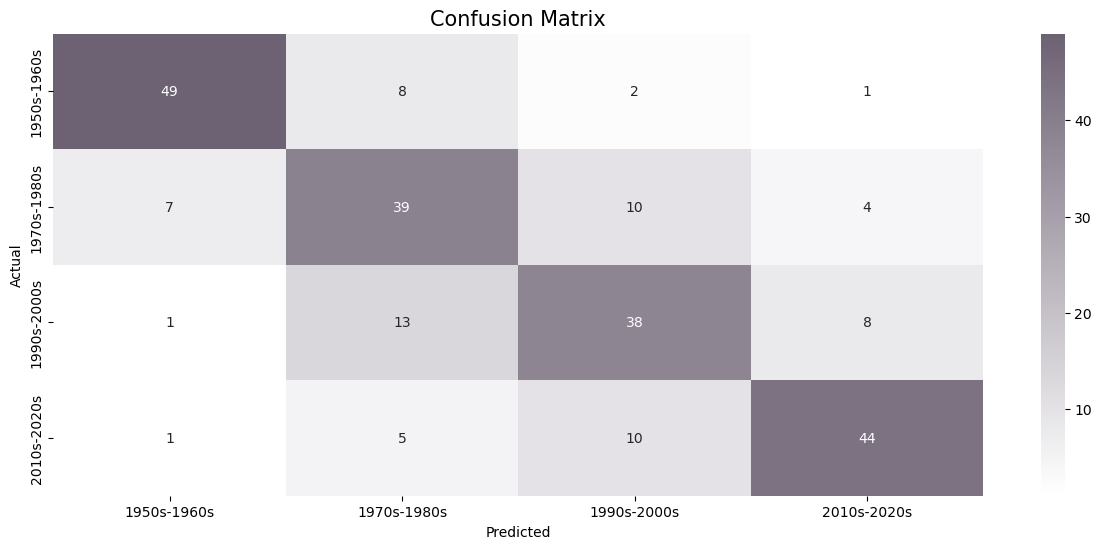

In [47]:
# Custom color map
colors = ['#ffffff', '#6d6273'] 
n_bins = 100
cmap_name = 'custom_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(15,6))
sns.heatmap(cm, annot=True, fmt='d', cmap=custom_cmap, xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix',size=15)
plt.show()

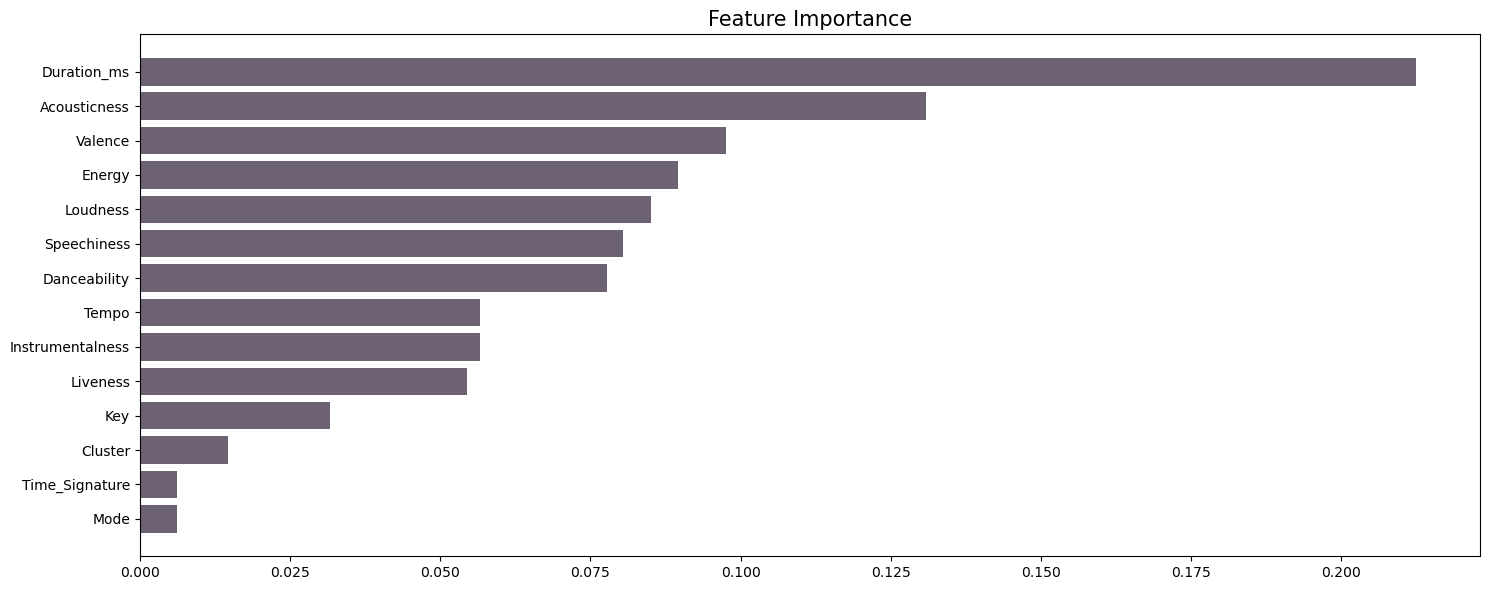

In [48]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::1]
features = X_train.columns

plt.figure(figsize=(15,6))
plt.title("Feature Importance",size=15)
plt.barh(range(X_train.shape[1]), importances[indices], align="center", color='#6d6273')
plt.yticks(range(X_train.shape[1]), [features[i] for i in indices])
plt.tight_layout()
plt.show()

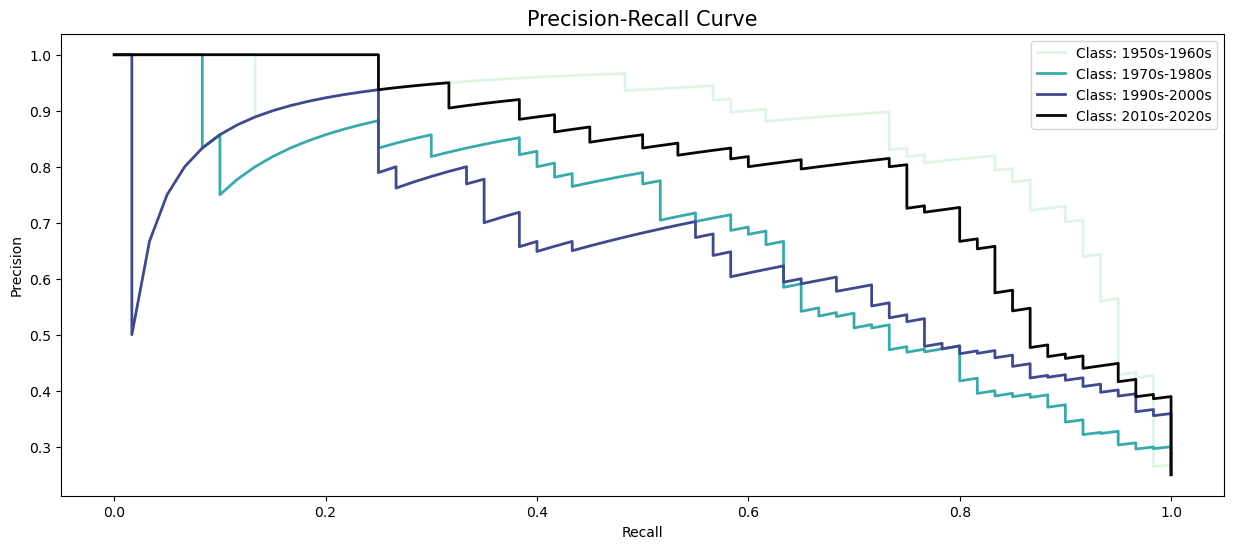

In [49]:
cmap = plt.get_cmap('mako_r')
y_prob = best_rf.predict_proba(X_test)

plt.figure(figsize=(15,6))
colors = cmap(np.linspace(0, 1, len(le.classes_)))

for i, (label, color) in enumerate(zip(le.classes_, colors)):
    precision, recall, _ = precision_recall_curve(y_test == i, y_prob[:, i])
    plt.plot(recall, precision, lw=2, label=f'Class: {label}', color=color)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve', size=15)
plt.legend(loc='best')
plt.show()

In [50]:
joblib.dump(best_rf, 'song_classification_model.pkl')

['song_classification_model.pkl']

In [51]:
joblib.dump(a_scaler, 'a_scaler.pkl')
joblib.dump(kmeans, 'kmeans.pkl')
joblib.dump(ewd_lo_disc, 'ewd_lo_disc.pkl')
#joblib.dump(b_scaler, 'b_scaler.pkl')

['ewd_lo_disc.pkl']